# PSD

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def psd2(t, x0, name, L_ref=1.0, U_ref=1.0):
    # Parameters
    distance = 10.0  # time period for computing
    delta_t = t[1] - t[0]
    pos_start = int(distance // delta_t)

    # Modify signal and reset time
    t = t[pos_start:] - t[pos_start]
    x0 = x0[pos_start:]
    L = len(x0)

    # Frequency vector
    fs = 1.0 / delta_t  # sampling frequency
    f = np.fft.fftfreq(L, d=delta_t)
    f2_0 = f[:L//2]

    # FFT
    FFT0 = np.fft.fft(x0)
    P1_0 = (np.abs(FFT0) ** 2) / L  # power spectrum
    P2_0 = P1_0[:L//2]
    P2_0[1:-1] = 2 * P2_0[1:-1]  # single-sided

    # Convert to Strouhal number
    St = f2_0 * L_ref / U_ref

    # Find maximum PSD and corresponding St
    max_idx = np.argmax(P2_0)
    max_PSD = P2_0[max_idx]
    max_St = St[max_idx]

    print(f"Max PSD = {max_PSD:.6e} at St = {max_St:.6f}")

    # Plot PSD
    plt.figure(figsize=(4, 3))
    plt.loglog(St, P2_0, label="PSD")
    plt.xlabel("Frequency", fontsize=14)
    plt.ylabel("PSD", fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks([1e-4,1e-2,1,1e2,1e4],fontsize=14)
    plt.xlim(1e-3, 0.5)
    plt.ylim(bottom=1e-4, top=1e4)
    plt.grid(True, which="both", ls="-")
    

Max PSD = 1.470532e+04 at St = 0.000000


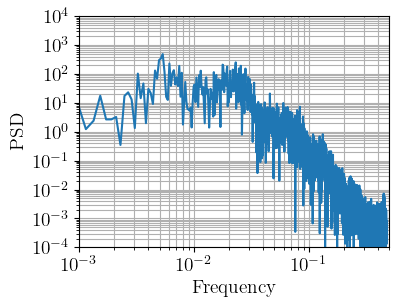

In [3]:
from func import *
[time,Nu]=readdata("Data/DNS/Flow_structure_classification/Ra100000/energy.asc",17)
psd2(time, Nu, "Data/DNS/Flow_structure_classification/Ra100000/Nu")
plt.savefig('Data/DNS/Flow_structure_classification/Ra100000/Nu_based_PSD.png', dpi=300, bbox_inches='tight')


Max PSD = 1.937273e+04 at St = 0.000000


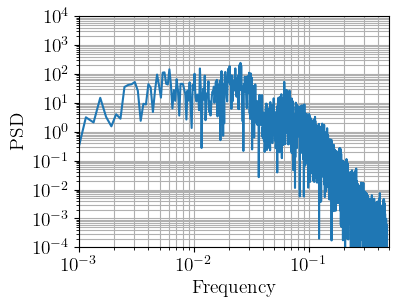

In [4]:
from func import *
[time,Nu]=readdata("Data/DNS/Flow_structure_classification/Ra150000/energy.asc",17)
psd2(time, Nu, "Data/DNS/Flow_structure_classification/Ra150000/Nu")
plt.savefig('Data/DNS/Flow_structure_classification/Ra150000/Nu_based_PSD.png', dpi=300, bbox_inches='tight')

Max PSD = 2.422490e+04 at St = 0.000000


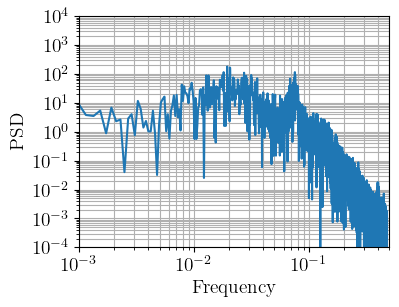

In [5]:
from func import *
[time,Nu]=readdata("Data/DNS/Flow_structure_classification/Ra200000/energy.asc",17)
psd2(time, Nu, "Data/DNS/Flow_structure_classification/Ra200000/Nu")
plt.savefig('Data/DNS/Flow_structure_classification/Ra200000/Nu_based_PSD.png', dpi=300, bbox_inches='tight')
